In [1]:
## Libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats

In [2]:

## Data Initialization
ticker_symbol = "^GSPC"

df_daily = yf.download(
    ticker_symbol,
    start="2000-01-01",
    end="2024-12-31",
    interval="1d",
    auto_adjust=True
)

# Flatten multi-level columns if present
df_daily.columns = df_daily.columns.get_level_values(0)


[*********************100%***********************]  1 of 1 completed


In [3]:

## Log Returns at Base Frequency (Daily)

df_daily['Log_Return'] = np.log(df_daily['Close'] / df_daily['Close'].shift(1))
df_daily.dropna(subset=['Log_Return'], inplace=True)

# Base return series — everything built from this
r_base = df_daily['Log_Return'].values

In [4]:

## Aggregate Returns by Summing (NOT resampling prices)
## Sum of log returns = exact multi-period log return

def aggregate_returns(r, window):
    """
    Aggregate daily log returns into non-overlapping windows.
    Returns array of summed log returns over each window.
    
    Parameters:
        r      : np.array of daily log returns
        window : int, number of days to aggregate
    
    Returns:
        np.array of aggregated returns
    """
    n = len(r)
    n_windows = n // window  # number of complete windows only
    r_trimmed = r[:n_windows * window]  # trim incomplete final window
    return r_trimmed.reshape(n_windows, window).sum(axis=1)

# Build aggregated return series for each timescale
tau_labels = ["1_day", "5_day", "10_day", "15_day"]
tau_windows = [1, 5, 10, 15]  # in trading days

return_series = {}
for label, window in zip(tau_labels, tau_windows):
    return_series[label] = aggregate_returns(r_base, window)
    print(f"{label}: {len(return_series[label])} observations")


1_day: 6287 observations
5_day: 1257 observations
10_day: 628 observations
15_day: 419 observations


In [5]:
##-----------------------
## Structure Functions S_q(tau)
##-----------------------
q_orders = [1, 2, 3, 4]  # moment orders

def compute_structure_function(r, q):
    """
    Compute q-th order structure function.
    S_q = mean(|r|^q)
    
    Parameters:
        r : np.array of returns at a given timescale
        q : int, moment order
    
    Returns:
        float, S_q value
    """
    return np.mean(np.abs(r) ** q)

# Compute S_q for every combination of tau and q
# Store as dictionary: sq_matrix[q][tau_label] = S_q(tau)
sq_matrix = {q: {} for q in q_orders}

for q in q_orders:
    for label in tau_labels:
        sq_matrix[q][label] = compute_structure_function(return_series[label], q)

# Print results table
print("\n--- Structure Function Matrix S_q(tau) ---")
print(f"{'tau':<12}", end="")
for q in q_orders:
    print(f"{'q=' + str(q):<15}", end="")
print()

for label in tau_labels:
    print(f"{label:<12}", end="")
    for q in q_orders:
        print(f"{sq_matrix[q][label]:<15.6f}", end="")
    print()


--- Structure Function Matrix S_q(tau) ---
tau         q=1            q=2            q=3            q=4            
1_day       0.008099       0.000150       0.000005       0.000000       
5_day       0.017818       0.000676       0.000049       0.000006       
10_day      0.024073       0.001060       0.000071       0.000006       
15_day      0.031043       0.001965       0.000236       0.000043       


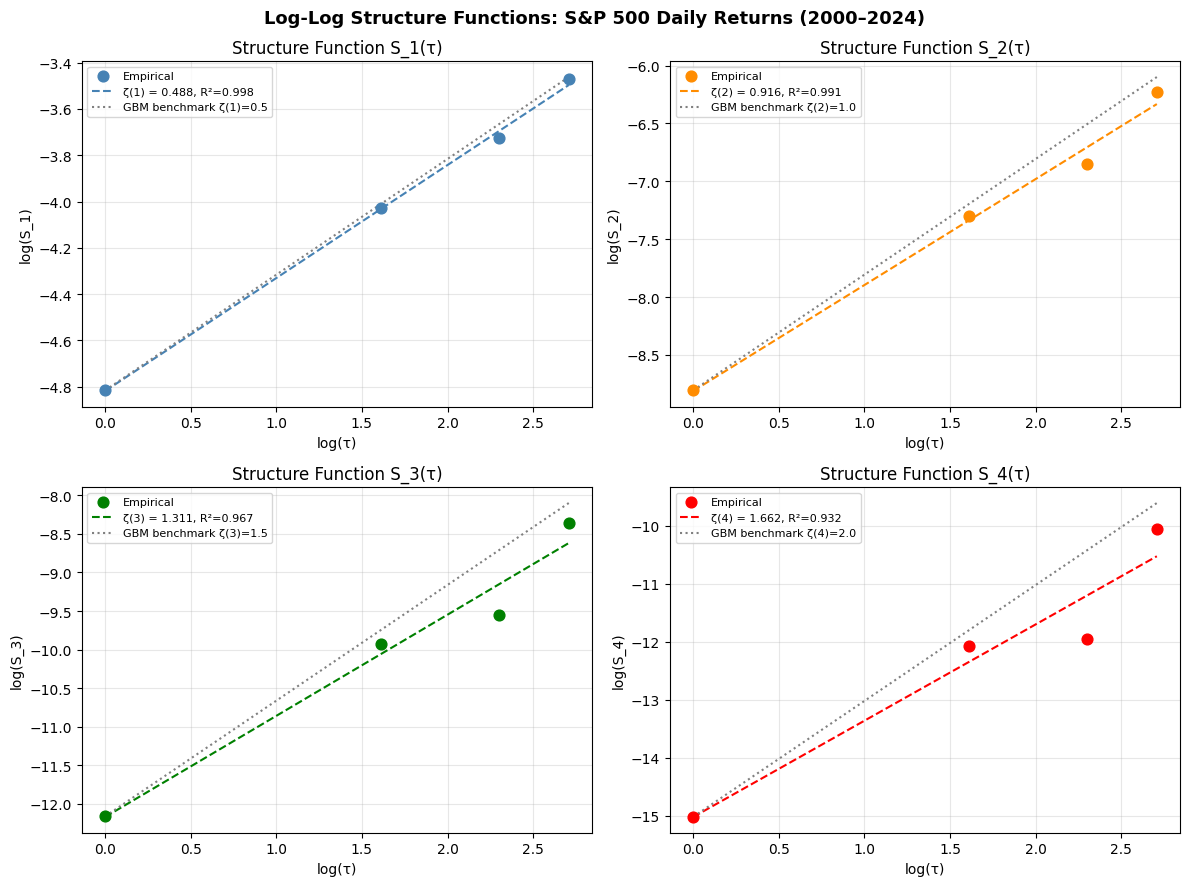


--- Scaling Exponents ζ(q) ---
q      ζ(q) empirical       ζ(q) GBM benchmark  
1      0.4882               0.5000              
2      0.9158               1.0000              
3      1.3115               1.5000              
4      1.6619               2.0000              


In [6]:
##-----------------------
## Log-Log Plot: log S_q(tau) vs log(tau)
##-----------------------
tau_values = np.array(tau_windows)  # [1, 5, 10, 15]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'green', 'red']

for idx, q in enumerate(q_orders):
    sq_values = np.array([sq_matrix[q][label] for label in tau_labels])

    log_tau = np.log(tau_values)
    log_sq  = np.log(sq_values)

    # OLS regression on log-log
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_tau, log_sq)

    # Plot empirical points
    axes[idx].scatter(log_tau, log_sq, color=colors[idx], zorder=5, s=60, label='Empirical')

    # Plot fitted line
    fitted = intercept + slope * log_tau
    axes[idx].plot(log_tau, fitted, color=colors[idx], linestyle='--',
                   label=f'ζ({q}) = {slope:.3f}, R²={r_value**2:.3f}')

    # GBM benchmark line: ζ(q) = q/2
    gbm_slope   = q / 2
    gbm_fitted  = log_sq[0] + gbm_slope * (log_tau - log_tau[0])
    axes[idx].plot(log_tau, gbm_fitted, color='grey', linestyle=':',
                   label=f'GBM benchmark ζ({q})={gbm_slope:.1f}')

    axes[idx].set_title(f'Structure Function S_{q}(τ)', fontsize=12)
    axes[idx].set_xlabel('log(τ)', fontsize=10)
    axes[idx].set_ylabel(f'log(S_{q})', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Log-Log Structure Functions: S&P 500 Daily Returns (2000–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('structure_functions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Scaling Exponents ζ(q) ---")
print(f"{'q':<6} {'ζ(q) empirical':<20} {'ζ(q) GBM benchmark':<20}")
for q in q_orders:
    sq_values = np.array([sq_matrix[q][label] for label in tau_labels])
    slope, _, r_value, _, std_err = stats.linregress(np.log(tau_values), np.log(sq_values))
    print(f"{q:<6} {slope:<20.4f} {q/2:<20.4f}")





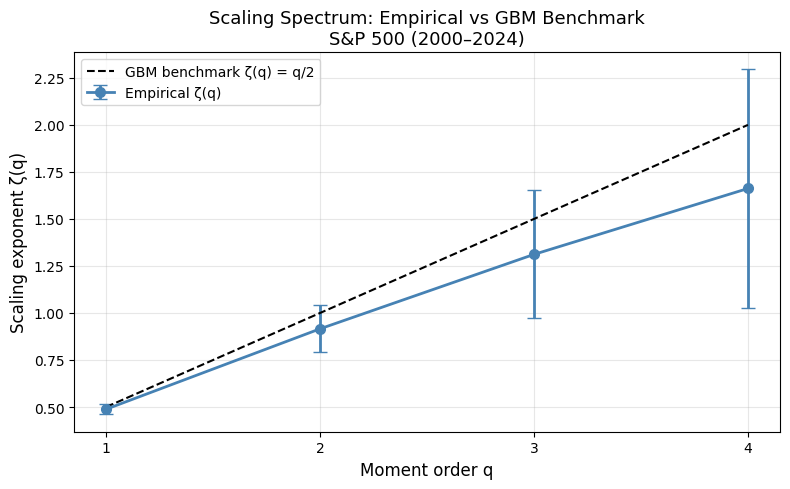


--- Concavity of ζ(q) ---
If empirical ζ(q) is concave in q → multiscaling confirmed
Second differences of ζ(q): [-0.03191687 -0.0452651 ]
All negative (concave): True


In [7]:
##-----------------------
## Scaling Spectrum Plot: ζ(q) vs q
##-----------------------
empirical_zeta = []
gbm_zeta = []
std_errors = []

for q in q_orders:
    sq_values = np.array([sq_matrix[q][label] for label in tau_labels])
    slope, _, _, _, std_err = stats.linregress(np.log(tau_values), np.log(sq_values))
    empirical_zeta.append(slope)
    gbm_zeta.append(q / 2)
    std_errors.append(std_err)

empirical_zeta = np.array(empirical_zeta)
gbm_zeta = np.array(gbm_zeta)
std_errors = np.array(std_errors)

plt.figure(figsize=(8, 5))

# Empirical scaling spectrum with error bars
plt.errorbar(q_orders, empirical_zeta, yerr=2*std_errors,
             fmt='o-', color='steelblue', capsize=5,
             label='Empirical ζ(q)', linewidth=2, markersize=7)

# GBM benchmark — linear
plt.plot(q_orders, gbm_zeta, 'k--',
         label='GBM benchmark ζ(q) = q/2', linewidth=1.5)

# Formatting
plt.xlabel('Moment order q', fontsize=12)
plt.ylabel('Scaling exponent ζ(q)', fontsize=12)
plt.title('Scaling Spectrum: Empirical vs GBM Benchmark\nS&P 500 (2000–2024)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(q_orders)
plt.tight_layout()
plt.savefig('scaling_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# Concavity check
print("\n--- Concavity of ζ(q) ---")
print("If empirical ζ(q) is concave in q → multiscaling confirmed")
second_diff = np.diff(empirical_zeta, n=2)
print(f"Second differences of ζ(q): {second_diff}")
print(f"All negative (concave): {all(second_diff < 0)}")